In [2]:
pip install numpy pandas matplotlib seaborn statsmodels scikit-learn



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
pip install pkl

ERROR: Could not find a version that satisfies the requirement pkl (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for pkl
Note: you may need to restart the kernel to use updated packages.


/var/folders/w1/9gqnn9m96xb_2s02x1sv18qc0000gn/T/ipykernel_7570/646298859.py:121: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data["cdrObject.total_energy"].replace(0, np.nan).fillna(method='bfill').values
/var/folders/w1/9gqnn9m96xb_2s02x1sv18qc0000gn/T/ipykernel_7570/646298859.py:149: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace([np.inf, -np.inf], np.nan, inplace=True)
/var/folders/w1/9gqnn9m96xb_2s02x1sv18qc0000gn/T/ipykernel_7570/646298859.py:150: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.fillna(0, inplace=Tr

Mean Absolute Error (MAE): 1.8521
R² Score: 0.9884


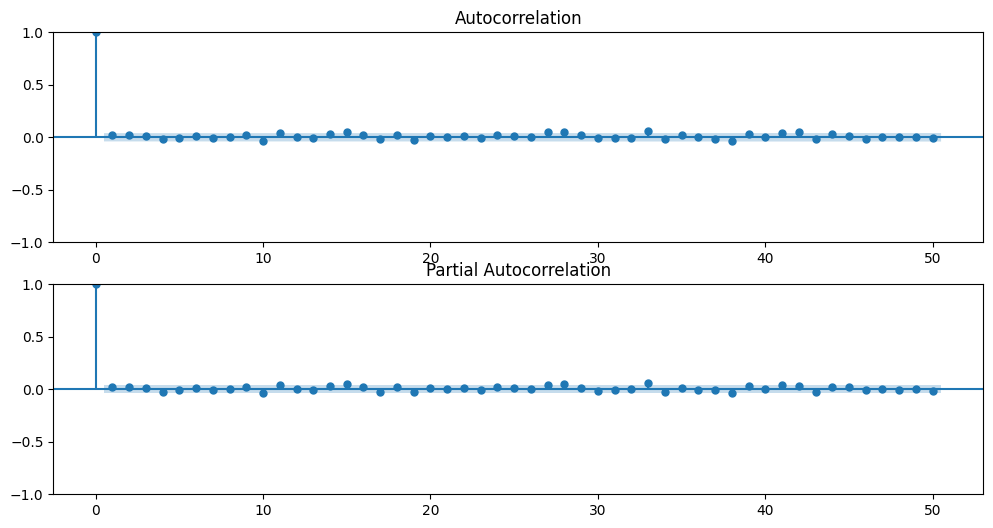

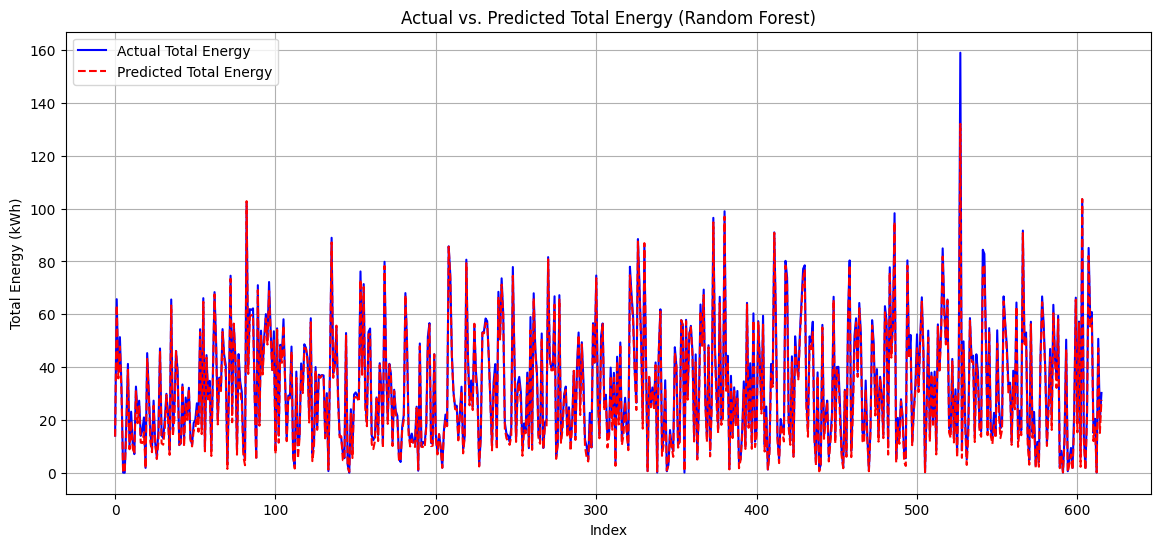

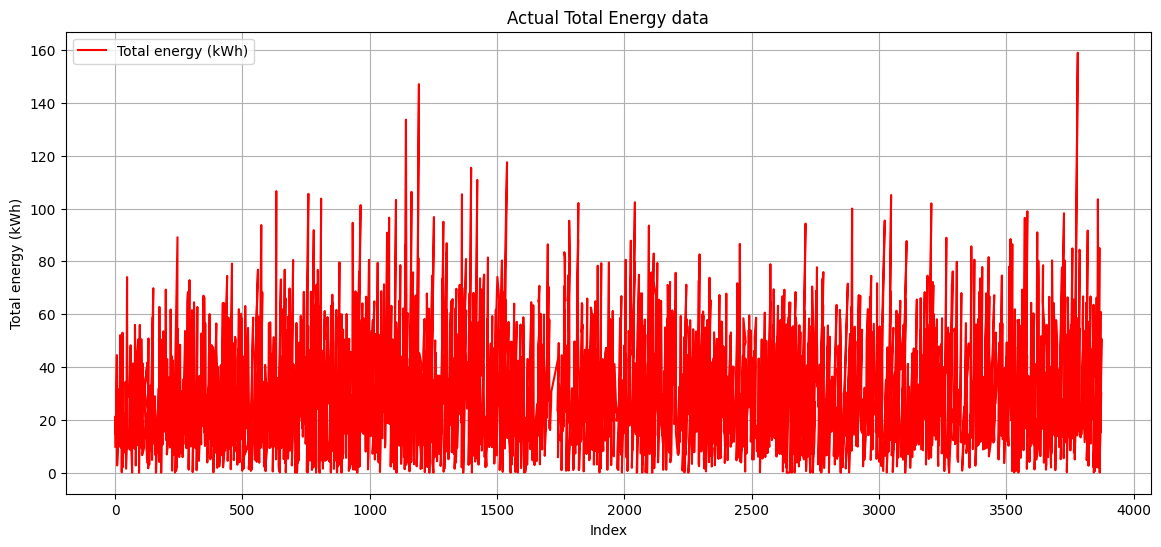

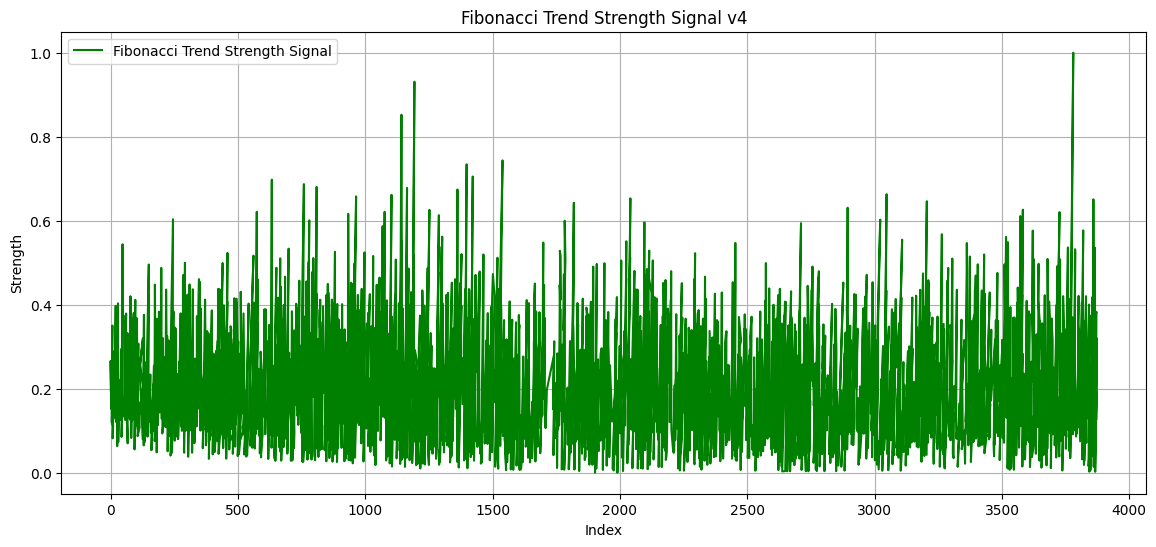

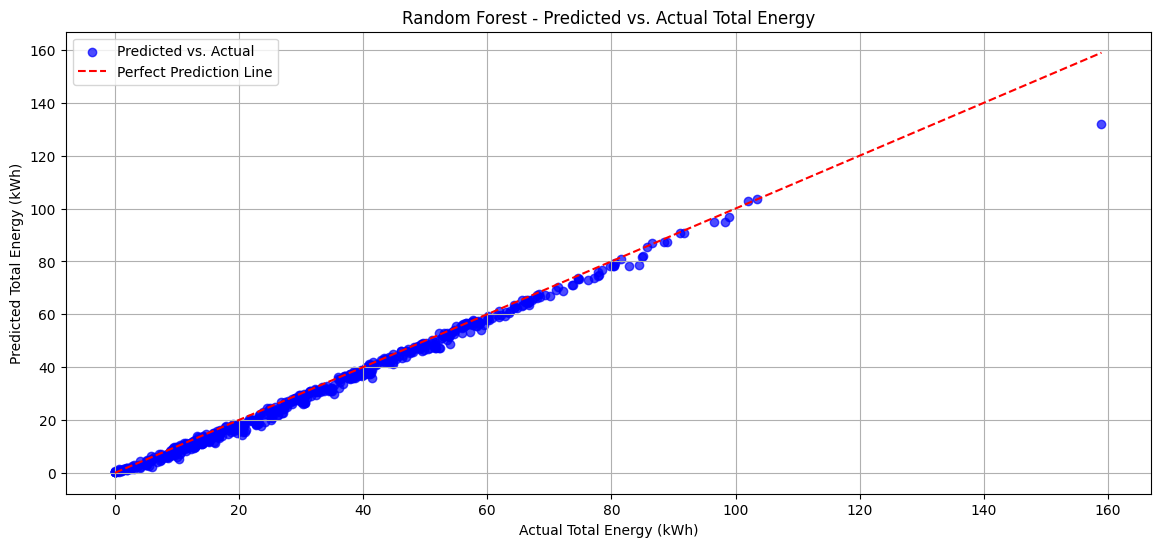

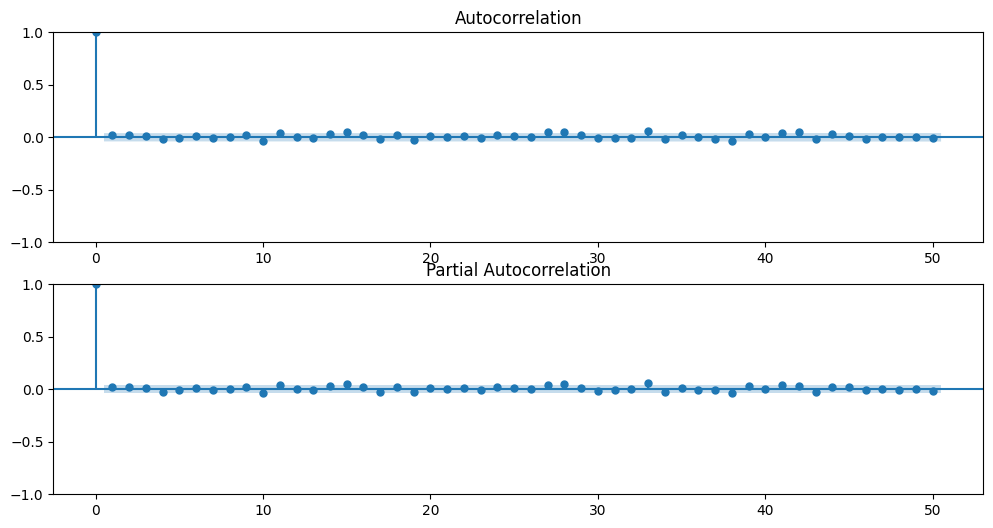

In [18]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, r2_score
from functools import lru_cache
import pickle
from sklearn.datasets import make_regression


# ✅ Load JSON Data Using pd.json_normalize
with open("full_data.json") as f:  # Replace with actual file path
    data = pd.json_normalize(json.load(f))

data = data[data['cdrObject.total_energy']>0]

# ✅ Convert DateTime Fields
data["cdrObject.start_date_time"] = pd.to_datetime(data["cdrObject.start_date_time"], utc=True)
data["cdrObject.stop_date_time"] = pd.to_datetime(data["cdrObject.stop_date_time"], utc=True)

data['cdrObject.start_date_time'] = pd.to_datetime(data['cdrObject.start_date_time'], utc=True)
data['start_year'] = [x.year for x in data['cdrObject.start_date_time']]
data['start_month'] = [x.month for x in data['cdrObject.start_date_time']]
data['start_day'] = [x.day for x in data['cdrObject.start_date_time']]
data['start_week_day'] = [x.weekday() for x in data['cdrObject.start_date_time']]
data['rate'] = data['cdrObject.total_cost'] / data ['cdrObject.total_energy']
data['is_weekend'] = data['start_week_day'].apply(lambda x: 1 if x in [5, 6] else 0)
data['session_duration_hours'] = data['cdrObject.total_time'] / 60
data['month_sin'] = np.sin(2 * np.pi * data['start_month']/12)
data['month_cos'] = np.cos(2 * np.pi * data['start_month']/12)
data['week_sin'] = np.sin(2 * np.pi * data['start_week_day'] / 7)
data['week_cos'] = np.cos(2 * np.pi * data['start_week_day'] / 7)
data = data.sort_values('cdrObject.start_date_time')

def extract_first_voltage(evse_list):
    if isinstance(evse_list, list) and len(evse_list) > 0:
        for evse in evse_list:
            if 'connectors' in evse and isinstance(evse['connectors'], list):
                for connector in evse['connectors']:
                    if 'voltage' in connector:
                        return connector['voltage']  # Return first found voltage
    return np.nan  # Return NaN if no voltage found

# Create new column with extracted 'voltage'
data['cdrObject.location.evses.connectors.voltage'] = data['cdrObject.location.evses'].apply(extract_first_voltage)

# ✅ Extract Time-Based Features
data["start_year"] = data["cdrObject.start_date_time"].dt.year
data["start_month"] = data["cdrObject.start_date_time"].dt.month
data["start_day"] = data["cdrObject.start_date_time"].dt.day
data["start_hour"] = data["cdrObject.start_date_time"].dt.hour
data["start_week_day"] = data["cdrObject.start_date_time"].dt.weekday
data["is_weekend"] = data["start_week_day"].apply(lambda x: 1 if x in [5, 6] else 0)

# ✅ Compute Session Metrics
data["charging_duration_hours"] = (data["cdrObject.stop_date_time"] - data["cdrObject.start_date_time"]).dt.total_seconds() / 3600

# ✅ Fix Division by Zero in `rate`
data["rate"] = np.where(data["cdrObject.total_energy"] > 0, 
                        data["cdrObject.total_cost"] / data["cdrObject.total_energy"], 0)

data["session_duration_hours"] = data["cdrObject.total_time"] / 60

# ✅ Apply Cyclical Encoding for Time Features
data["month_sin"] = np.sin(2 * np.pi * data["start_month"] / 12)
data["month_cos"] = np.cos(2 * np.pi * data["start_month"] / 12)
data["week_sin"] = np.sin(2 * np.pi * data["start_week_day"] / 7)
data["week_cos"] = np.cos(2 * np.pi * data["start_week_day"] / 7)

# ✅ Sort Data Chronologically
data = data.sort_values("cdrObject.start_date_time")

# ✅ Compute Rolling Averages for Historical Trends
data["total_energy_7d_avg"] = data["cdrObject.total_energy"].rolling(window=7, min_periods=1).mean()
data["total_energy_30d_avg"] = data["cdrObject.total_energy"].rolling(window=30, min_periods=1).mean()

# ✅ Fibonacci Trend Strength (V4)
@lru_cache(maxsize=None)
def fibonacci_upto_n(n):
    """Generates Fibonacci sequence up to 'n' with caching."""
    fib = [1, 1]
    while fib[-1] < n:
        fib.append(fib[-1] + fib[-2])
    return fib[:-1]

def fibonacci_trend_strength_v4(data, base_alpha=0.01, max_windows=10):
    """Computes Fibonacci Trend Strength for given energy data."""
    data = np.ravel(data)
    max_val = np.max(data)  # Get max value for scaling
    if max_val > 0:
        data /= max_val  # Normalize

    n = len(data)
    trend_strength = np.zeros(n)

    volatility = pd.Series(data).rolling(window=5, min_periods=1).std().shift(1).fillna(0)
    dynamic_alpha = base_alpha * (1 + volatility / np.mean(volatility))

    for i in range(1, n):
        fib_windows = np.array(fibonacci_upto_n(i))
        valid_windows = fib_windows[fib_windows <= i][-max_windows:]

        if len(valid_windows) == 0:
            continue

        window_avgs = pd.Series(data).rolling(window=valid_windows[-1], min_periods=1).mean().shift(1).values[i]
        weights = np.exp(-dynamic_alpha[i] / valid_windows[-1])
        weighted_diff = weights * (data[i] - window_avgs)

        trend_strength[i] = np.sum(weighted_diff) / np.sum(weights)

    return trend_strength * max_val  # Convert back to original scale

# ✅ Apply Fibonacci Trend Strength with Scaling
data["fibonacci_trend"] = fibonacci_trend_strength_v4(
    data["cdrObject.total_energy"].replace(0, np.nan).fillna(method='bfill').values
)
data['SMA'] = data['cdrObject.total_energy'].rolling(window=7).mean()
data['EMA'] = data['cdrObject.total_energy'].ewm(span=7, adjust=False).mean()

# ✅ Normalize Fibonacci Trend Using MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
data["fibonacci_trend"] = scaler.fit_transform(data[["fibonacci_trend"]])
# ✅ Prepare Dataset for Modeling
# X = data[[
#     "charging_duration_hours", "rate", "session_duration_hours", 
#     "month_sin", "month_cos", "week_sin", "week_cos",
#     "total_energy_7d_avg", "total_energy_30d_avg", "fibonacci_trend"
# ]]

X = data[[
    "start_day", "start_hour", "is_weekend", "start_week_day", 
    # 'EMA', 'SMA', 'fibonacci_trend'
    "fibonacci_trend"
]]


# X = data[[
#     "fibonacci_trend"
# ]]
y = data["cdrObject.total_energy"]

# ✅ Remove NaN or Inf from X
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# ✅ Split Data into Train/Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False, random_state=42)

# ✅ Train Random Forest Model
rf_model = RandomForestRegressor(
    n_estimators=100, 
    min_samples_split=5,
    max_depth=15, 
    random_state=42,)
rf_model.fit(X_train, y_train)

with open('model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# ✅ Make Predictions
predictions = rf_model.predict(X_test)

# ✅ Evaluate Model Performance
mae_rf = mean_absolute_error(y_test, predictions)
r2_rf = r2_score(y_test, predictions)

# ✅ Print Model Performance
print(f"Mean Absolute Error (MAE): {mae_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
sm.graphics.tsa.plot_acf(y_train, lags=50, ax=ax[0])  # Autocorrelation
sm.graphics.tsa.plot_pacf(y_train, lags=50, ax=ax[1])  # Partial Autocorrelation
plt.show()

# ✅ Plot Actual vs. Predicted Total Energy (Line Plot)
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label="Actual Total Energy", color="blue", linestyle="-")
plt.plot(predictions, label="Predicted Total Energy", color="red", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Total Energy (kWh)")
plt.title("Actual vs. Predicted Total Energy (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Plot actual total energy data
plt.figure(figsize=(14, 6))
plt.plot(data["cdrObject.total_energy"], label="Total energy (kWh)", color="red")
plt.xlabel("Index")
plt.ylabel("Total energy (kWh)")
plt.title("Actual Total Energy data")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Plot Fibonacci Trend Strength Signal
plt.figure(figsize=(14, 6))
plt.plot(data["fibonacci_trend"], label="Fibonacci Trend Strength Signal", color="green")
plt.xlabel("Index")
plt.ylabel("Strength")
plt.title("Fibonacci Trend Strength Signal v4")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Plot Actual vs. Predicted Total Energy
plt.figure(figsize=(14, 6))
plt.scatter(y_test, predictions, alpha=0.7, color="blue", label="Predicted vs. Actual")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", label="Perfect Prediction Line")
plt.xlabel("Actual Total Energy (kWh)")
plt.ylabel("Predicted Total Energy (kWh)")
plt.title("Random Forest - Predicted vs. Actual Total Energy")
plt.legend()
plt.grid(True)
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(12, 6))
sm.graphics.tsa.plot_acf(y_train, lags=50, ax=ax[0])  # Autocorrelation
sm.graphics.tsa.plot_pacf(y_train, lags=50, ax=ax[1])  # Partial Autocorrelation
plt.show()

In [4]:
train_predictions = rf_model.predict(X_train)
# Compute MAE and R² for training set
mae_train = mean_absolute_error(y_train, train_predictions)
r2_train = r2_score(y_train, train_predictions)
# Compute MAE and R² for test set
mae_test = mean_absolute_error(y_test, predictions)
r2_test = r2_score(y_test, predictions)

# ✅ Print Overfitting Evaluation
print("Overfitting Test Results:")
print(f"Train Set - MAE: {mae_train:.4f}, R² Score: {r2_train:.4f}")
print(f"Test Set - MAE: {mae_test:.4f}, R² Score: {r2_test:.4f}")

# ✅ Check Overfitting Condition
if mae_train < mae_test * 0.8 and r2_train > r2_test + 0.1:
    print("⚠️ Model is likely Overfitting! Consider reducing tree depth or using regularization.")
elif mae_train > mae_test:
    print("⚠️ Model may be Underfitting. Try increasing model complexity.")
else:
    print("✅ Model is well-generalized.")

Overfitting Test Results:
Train Set - MAE: 0.9352, R² Score: 0.9965
Test Set - MAE: 1.4342, R² Score: 0.9908
✅ Model is well-generalized.



Model Evaluation Metrics:
     Metric     Value
0       MAE  1.852133
1       MSE  5.965165
2      RMSE  2.442369
3      MAPE  0.188149
4     MedAE  1.658803
5  R² Score  0.988360


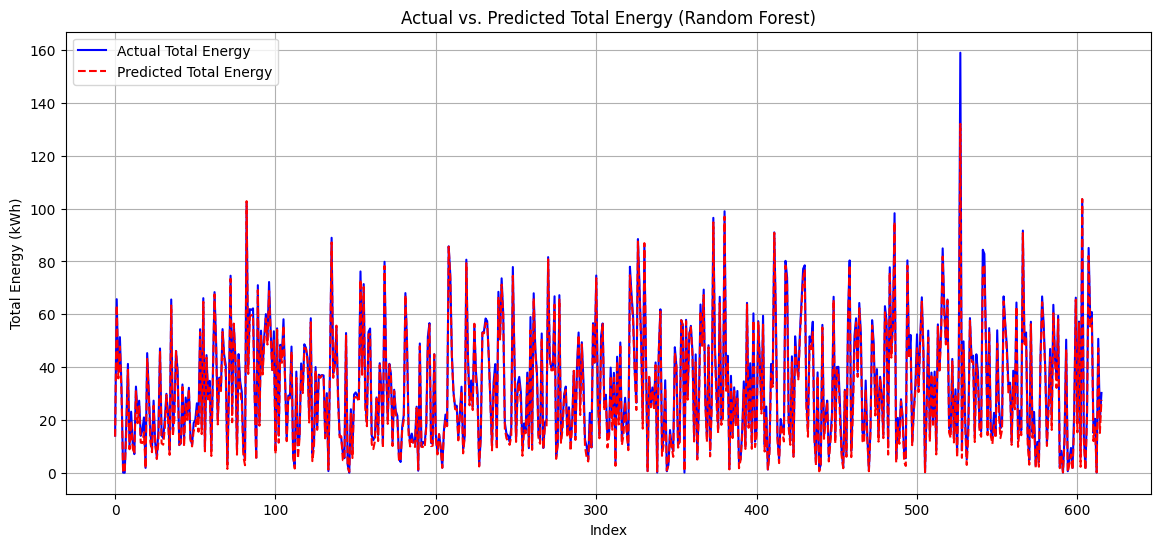

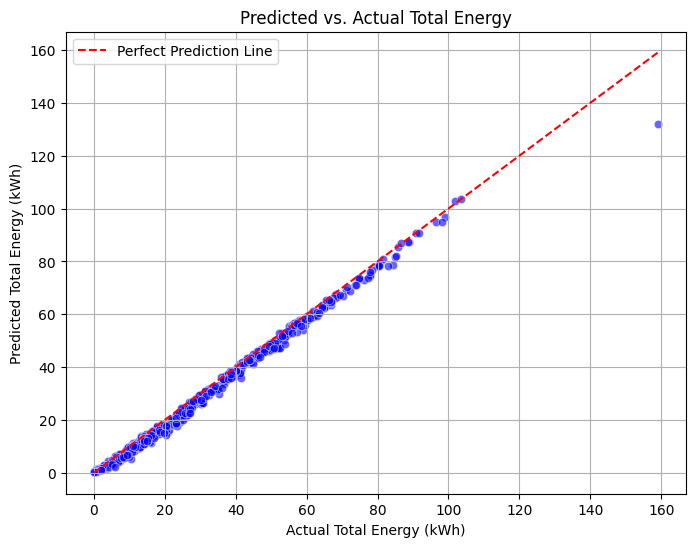

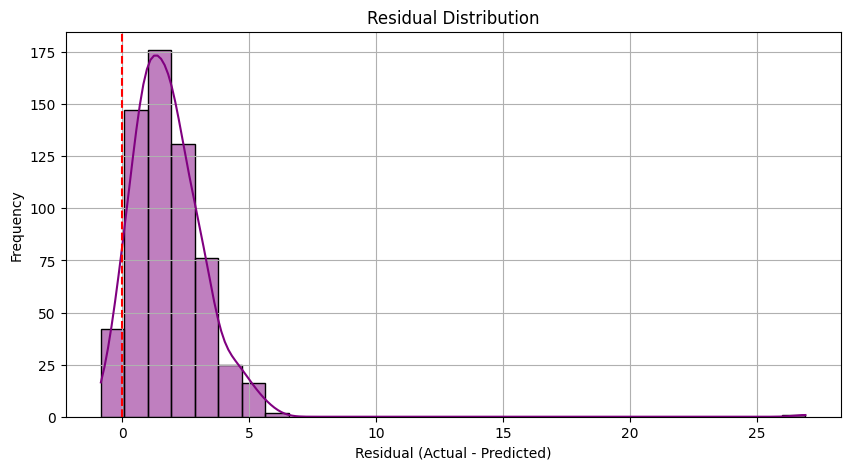

Skewness of residuals: 6.190864641493815


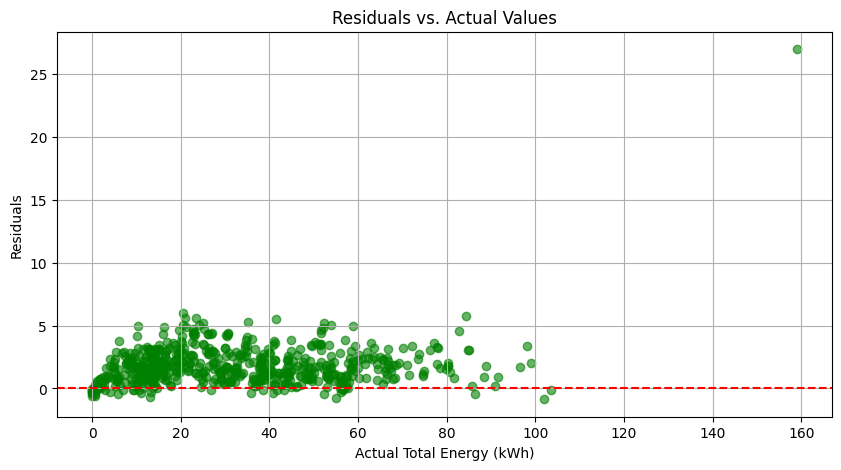

In [15]:
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import statsmodels.api as sm
from scipy.stats import skew

# ✅ Compute Various Evaluation Metrics
mae_test = mean_absolute_error(y_test, predictions)  # Mean Absolute Error (MAE)
mse_test = mean_squared_error(y_test, predictions)  # Mean Squared Error (MSE)
rmse_test = np.sqrt(mse_test)  # Root Mean Squared Error (RMSE)
mape_test = mean_absolute_percentage_error(y_test, predictions)  # Mean Absolute Percentage Error (MAPE)
medae_test = median_absolute_error(y_test, predictions)  # Median Absolute Error (MedAE)
r2_test = r2_score(y_test, predictions)  # R² Score

# ✅ Store Metrics in DataFrame for Display
metrics_df = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "MAPE", "MedAE", "R² Score"],
    "Value": [mae_test, mse_test, rmse_test, mape_test, medae_test, r2_test]
})

# ✅ Display Metrics
print("\nModel Evaluation Metrics:")
print(metrics_df)

# ✅ Plot Actual vs. Predicted Total Energy (Line Plot)
plt.figure(figsize=(14, 6))
plt.plot(y_test.values, label="Actual Total Energy", color="blue", linestyle="-")
plt.plot(predictions, label="Predicted Total Energy", color="red", linestyle="--")
plt.xlabel("Index")
plt.ylabel("Total Energy (kWh)")
plt.title("Actual vs. Predicted Total Energy (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Scatter Plot for Predicted vs. Actual
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=predictions, alpha=0.6, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], linestyle="--", color="red", label="Perfect Prediction Line")
plt.xlabel("Actual Total Energy (kWh)")
plt.ylabel("Predicted Total Energy (kWh)")
plt.title("Predicted vs. Actual Total Energy")
plt.legend()
plt.grid(True)
plt.show()

# ✅ Residual Plot (Histogram)
residuals = y_test - predictions
# residuals = [x for x in residuals if x <= 10]
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="--")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.grid(True)
plt.show()
residual_skewness = skew(residuals)
print("Skewness of residuals:", residual_skewness)


# ✅ Residuals Scatter Plot
plt.figure(figsize=(10, 5))
plt.scatter(y_test, residuals, alpha=0.6, color="green")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Total Energy (kWh)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.grid(True)
plt.show()

In [26]:
# ✅ Compute Fibonacci Trend Strength
from functools import lru_cache

@lru_cache(maxsize=None)
def fibonacci_upto_n(n):
    fib = [1, 1]
    while fib[-1] < n:
        fib.append(fib[-1] + fib[-2])
    return fib[:-1]

def compute_fibonacci_trend_strength(data, base_alpha=0.01, max_windows=10):
    data = np.ravel(data)
    max_val = np.max(data) if np.max(data) > 0 else 1
    data /= max_val
    
    n = len(data)
    trend_strength = np.zeros(n)

    volatility = pd.Series(data).rolling(window=5, min_periods=1).std().fillna(0)
    dynamic_alpha = base_alpha * (1 + volatility / np.mean(volatility))

    for i in range(1, n):
        fib_windows = np.array(fibonacci_upto_n(i))
        valid_windows = fib_windows[fib_windows <= i][-max_windows:]

        if len(valid_windows) == 0:
            continue

        window_avgs = pd.Series(data).rolling(window=valid_windows[-1], min_periods=1).mean().values[i]
        weights = np.exp(-dynamic_alpha[i] / valid_windows[-1])
        weighted_diff = weights * (data[i] - window_avgs)

        trend_strength[i] = np.sum(weighted_diff) / np.sum(weights)

    return trend_strength * max_val

def next_trend_strength(data, base_alpha=0.01, max_windows=10):
    """Returns the next trend strength point."""
    trend_strength = fibonacci_trend_strength_v4(data, base_alpha, max_windows)
    return trend_strength[-1]


-0.6000000000000001 -1.4


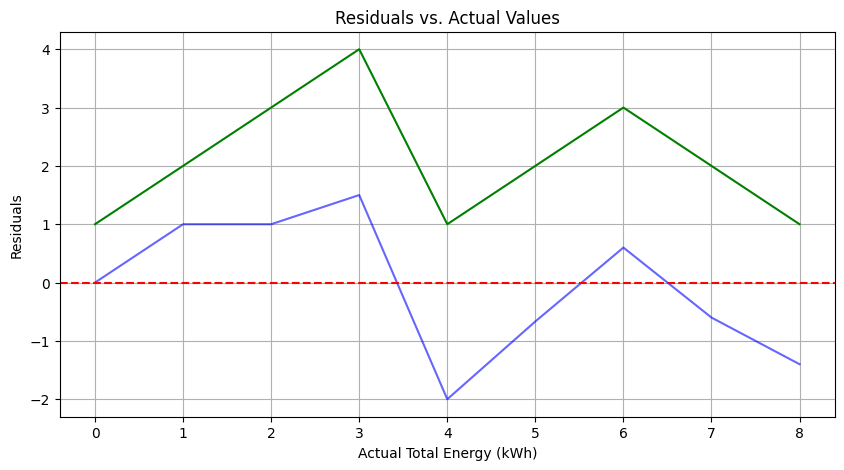

In [30]:
a=[1.0,2.0,3.0,4.0,1.0,2.0,3.0,2.0,1.0]

fib_strength=fibonacci_trend_strength_v4(a)

x=next_trend_strength(a[:-1])
print(x, fib_strength[-1])

plt.figure(figsize=(10, 5))
plt.plot(a, alpha=1, color="green")
plt.plot(fib_strength, alpha=0.6, color="blue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Actual Total Energy (kWh)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Actual Values")
plt.grid(True)
plt.show()

In [3]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn
!pip install statsmodels
!pip install scikit-learn
!pip install tensorflow
!pip install xgboost
!pip install --upgrade neuralprophet
!pip install git+https://github.com/amazon-science/chronos-forecasting.git


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
ERROR: No matching distribution found for tensorflow
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 17.7 

In [5]:
pip install chronos-forecasting


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


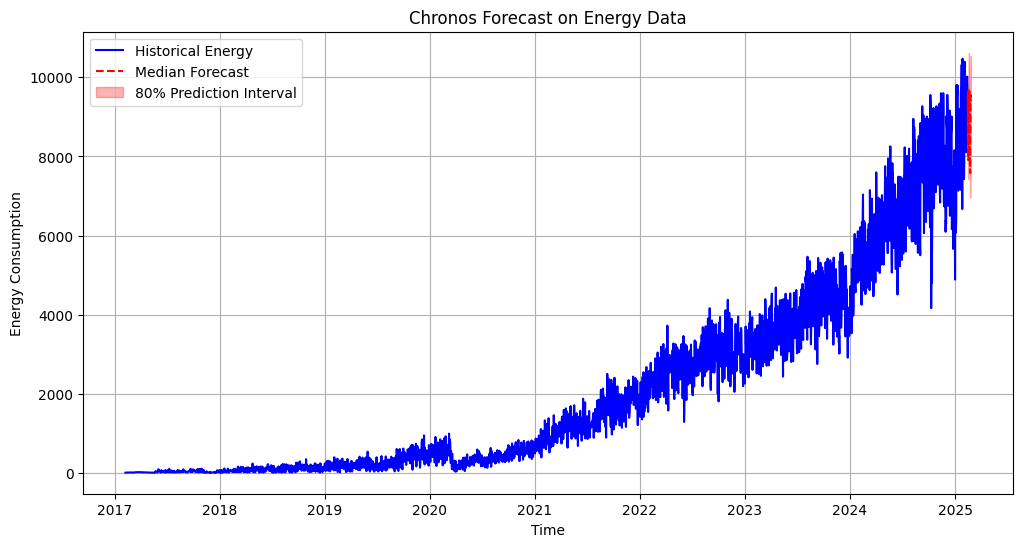

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import BaseChronosPipeline

# -----------------------------
# 1️⃣ Load & Preprocess Your Data
# -----------------------------
df = pd.read_csv("Query Result Feb 19 2025.csv")
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df = df.iloc[:-1]  # Drop the last row if needed

# -----------------------------
# 2️⃣ Initialize Chronos Pipeline on CPU
# -----------------------------
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",         # Use CPU since CUDA is not available
    torch_dtype=torch.float32  # float32 is recommended for CPU inference
)

# -----------------------------
# 3️⃣ Prepare Input and Forecast
# -----------------------------
# Convert your 'energy' column to a 1D tensor
context = torch.tensor(df['energy'].values, dtype=torch.float32)

# Set the number of steps to forecast
prediction_length = 12

# Get quantile forecasts: 10th, 50th (median), and 90th percentiles
quantiles, mean = pipeline.predict_quantiles(
    context=context,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9]
)

# For a single time series, extract the first batch item
quantiles = quantiles[0]  # Shape: [prediction_length, 3]
median_forecast = quantiles[:, 1].tolist()  # 0.5 quantile (median forecast)
low_forecast = quantiles[:, 0].tolist()       # 0.1 quantile
high_forecast = quantiles[:, 2].tolist()      # 0.9 quantile

# -----------------------------
# 4️⃣ Plot the Forecast
# -----------------------------
last_date = df['time'].iloc[-1]
forecast_dates = pd.date_range(start=last_date, periods=prediction_length+1, freq='D')[1:]

plt.figure(figsize=(12, 6))
plt.plot(df['time'], df['energy'], label="Historical Energy", color="blue")
plt.plot(forecast_dates, median_forecast, label="Median Forecast", color="red", linestyle="--")
plt.fill_between(forecast_dates, low_forecast, high_forecast, color="red", alpha=0.3,
                 label="80% Prediction Interval")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Chronos Forecast on Energy Data")
plt.legend()
plt.grid(True)
plt.show()


Evaluation Metrics:
MAE:  1299.0108
MSE:  2162527.5150
RMSE: 1470.5535
MAPE: 15.22%


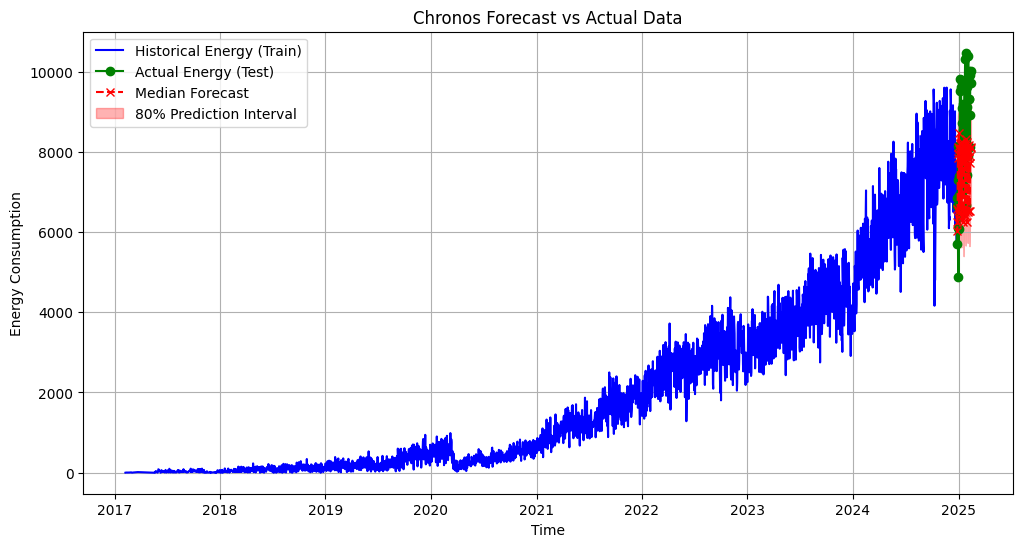

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from chronos import BaseChronosPipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# -----------------------------
# 1️⃣ Load & Preprocess Your Data
# -----------------------------
df = pd.read_csv("Query Result Feb 19 2025.csv")
df['time'] = pd.to_datetime(df['time'])
df = df.sort_values('time')
df = df.iloc[:-1]  # Drop the last row if needed

# -----------------------------
# 2️⃣ Split Data into Train and Test Sets
# -----------------------------
# Set the forecast horizon
prediction_length = 50

# Use the last 'prediction_length' rows as the test set
train_df = df.iloc[:-prediction_length].copy()
test_df = df.iloc[-prediction_length:].copy()

# -----------------------------
# 3️⃣ Initialize Chronos Pipeline on CPU
# -----------------------------
pipeline = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-t5-small",
    device_map="cpu",         # Using CPU because CUDA is not available
    torch_dtype=torch.float32  # Recommended dtype for CPU inference
)

# -----------------------------
# 4️⃣ Forecast Using the Training Data as Context
# -----------------------------
# Convert the training 'energy' column to a 1D tensor
context = torch.tensor(train_df['energy'].values, dtype=torch.float32)

# Get quantile forecasts for the next 'prediction_length' steps
quantiles, _ = pipeline.predict_quantiles(
    context=context,
    prediction_length=prediction_length,
    quantile_levels=[0.1, 0.5, 0.9]
)

# Extract forecasts for the first (and only) time series in the batch.
# The shape of quantiles is [batch_size, prediction_length, num_quantile_levels].
quantiles = quantiles[0]
median_forecast = quantiles[:, 1].tolist()  # 50th percentile (median forecast)
low_forecast    = quantiles[:, 0].tolist()    # 10th percentile
high_forecast   = quantiles[:, 2].tolist()    # 90th percentile

# -----------------------------
# 5️⃣ Evaluate the Forecast
# -----------------------------
# Extract the actual test values
y_true = test_df['energy'].values
y_pred = np.array(median_forecast)

mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
# Avoid division by zero in MAPE calculation
mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1e-6, y_true))) * 100

print("Evaluation Metrics:")
print(f"MAE:  {mae:.4f}")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.2f}%")

# -----------------------------
# 6️⃣ Plot the Forecast vs Actual Data
# -----------------------------
# Create forecast dates starting from the day after the last training date.
last_train_date = train_df['time'].iloc[-1]
forecast_dates = pd.date_range(start=last_train_date, periods=prediction_length+1, freq='D')[1:]

plt.figure(figsize=(12, 6))
plt.plot(train_df['time'], train_df['energy'], label="Historical Energy (Train)", color="blue")
plt.plot(test_df['time'], test_df['energy'], label="Actual Energy (Test)", color="green", marker="o")
plt.plot(forecast_dates, median_forecast, label="Median Forecast", color="red", linestyle="--", marker="x")
plt.fill_between(forecast_dates, low_forecast, high_forecast, color="red", alpha=0.3,
                 label="80% Prediction Interval")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Chronos Forecast vs Actual Data")
plt.legend()
plt.grid(True)
plt.show()


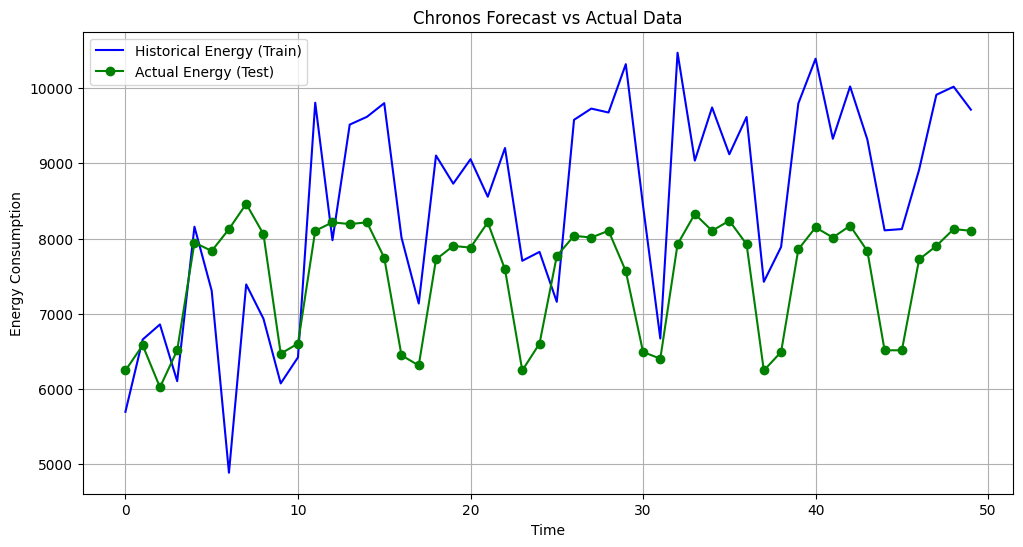

In [21]:
plt.figure(figsize=(12, 6))
plt.plot(y_true, label="Historical Energy (Train)", color="blue")
plt.plot(y_pred, label="Actual Energy (Test)", color="green", marker="o")
plt.xlabel("Time")
plt.ylabel("Energy Consumption")
plt.title("Chronos Forecast vs Actual Data")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
residuals= y_true-y_pred

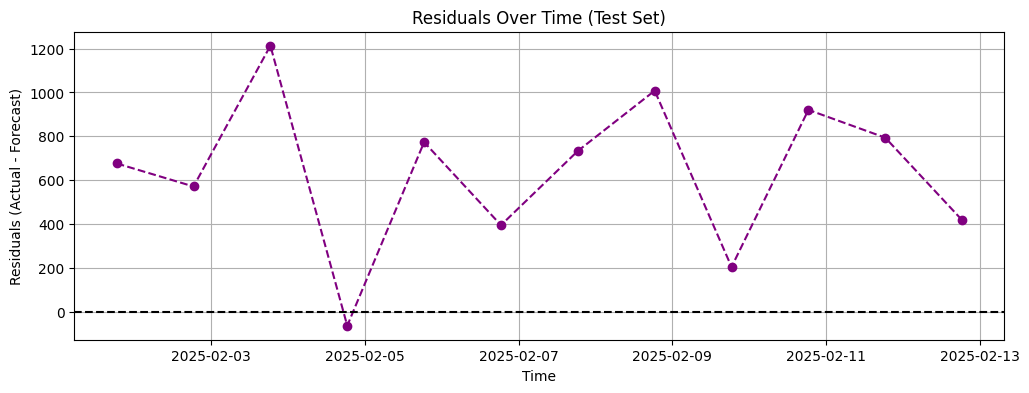

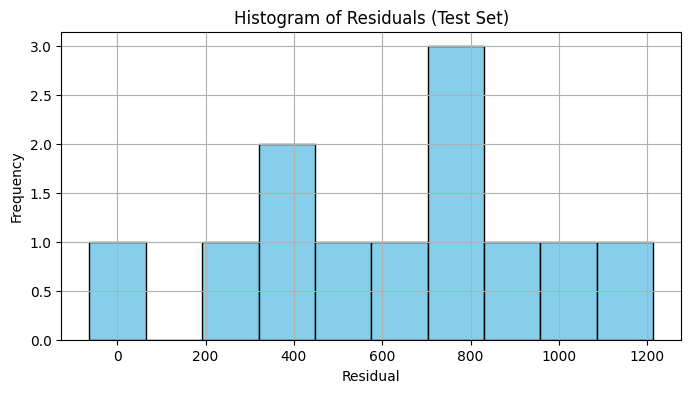

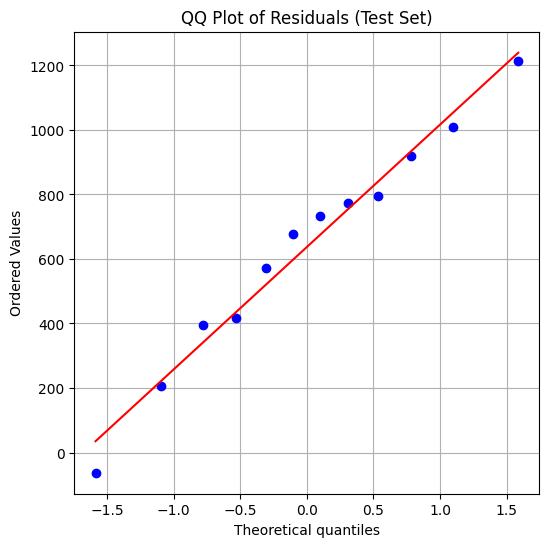

In [16]:
# a) Residuals Over Time
import scipy.stats as stats
plt.figure(figsize=(12, 4))
plt.plot(test_df['time'], residuals, marker="o", linestyle="--", color="purple")
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Time")
plt.ylabel("Residuals (Actual - Forecast)")
plt.title("Residuals Over Time (Test Set)")
plt.grid(True)
plt.show()

# b) Histogram of Residuals
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=10, color="skyblue", edgecolor="black")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals (Test Set)")
plt.grid(True)
plt.show()

# c) QQ Plot of Residuals
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ Plot of Residuals (Test Set)")
plt.grid(True)
plt.show()